In [29]:
from astropy.io import fits
from astropy.table import Table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('coolio!')

coolio!


In [30]:
# For Gal Spec Info
# Have to do this two more time ah!

hdul_infor = fits.open('../data/galSpecInfo-dr8.fits')
hdu1 = hdul_infor[1]
header = hdu1.header
#print(header)
data = hdu1.data
table = Table(data)

l1 = []
for name in table.colnames:
    if len(table[name].shape) <= 1:
        l1.append(name)
unidim1 = table[l1]

df_info = unidim1.to_pandas()
print(df_info.shape)

hdul_infor.close()

(1843200, 22)


In [31]:
# For Gal Spec Extra

hdul_extra = fits.open('../data/galSpecExtra-dr8.fits')
hdu2 = hdul_extra[1]
header2 = hdu2.header
#print(header2)
data2 = hdu2.data
table2 = Table(data2)

l2 = []
for name in table2.colnames:
    if len(table2[name].shape) <= 1:
        l2.append(name)
unidim2 = table2[l2]

df_extra = unidim2.to_pandas()
print(df_extra.shape)

hdul_infor.close()

(1843200, 45)


In [32]:
# For Gal Spec Lines

hdul_line = fits.open('../data/galSpecLine-dr8.fits')
hdu3 = hdul_line[1]
header3 = hdu3.header
#print(header)
data3 = hdu3.data
table3 = Table(data3)


l3 = []
for name in table3.colnames:
    if len(table3[name].shape) <= 1:
        l3.append(name)
unidim3 = table3[l3]

df_line = unidim3.to_pandas()
print(df_line.shape)

hdul_line.close()

(1843200, 241)


In [33]:
ids_match = (df_info['SPECOBJID'] == df_extra['SPECOBJID']).all() and (df_info['SPECOBJID'] == df_line['SPECOBJID']).all()
print(ids_match)

True


In [34]:
# Too many columns to just combine.... 
# master table with just the columns we need !!

dic1 = {
    'targettype': df_info['TARGETTYPE'].str.strip(),
    'redshift' : df_info['Z'],
    'reliable' : df_info['RELIABLE'],
    'log_mass' : df_extra['LGM_TOT_P50'],
    'sfr' : df_extra['SFR_TOT_P50'],
    'log_ssfr' : df_extra['SPECSFR_TOT_P50'],
    'bpt_class' : df_extra['BPTCLASS'],
    'ha_flux' : df_line['H_ALPHA_FLUX'],
    'ha_err' : df_line['H_ALPHA_FLUX_ERR'],
    'hb_flux' : df_line['H_BETA_FLUX'],
    'hb_err' : df_line['H_BETA_FLUX_ERR'],
    'oiii_flux' : df_line['OIII_5007_FLUX'],
    'oiii_err' : df_line['OIII_5007_FLUX_ERR'],
    'nii_flux' : df_line['NII_6584_FLUX'],
    'nii_err' : df_line['NII_6584_FLUX_ERR'],
}
master = pd.DataFrame(dic1)
print(master.shape)

(1843200, 15)


In [36]:
# Kauffman and Brinchman cut of the red shifts at 0.02 <= z <= 0.2. 
# Ony use reliablle data
# and also cut off placeholder values of - 9999 and all that ....

sample = master[(master['reliable'] == 1) & (master['targettype'] == 'GALAXY') & (master['redshift'] >= 0.02) & (master['redshift'] <= 0.2) & (master['log_mass'] > -9990) & (master['sfr'] > -9990) & (master['log_ssfr'] > -9990)
].copy()
print(sample.shape)
# print(sample.head())

# This is the table of all galaxies which satisfied all out cuts

(653944, 15)


In [37]:
agn = sample[ (sample['bpt_class'] == 4) & ((sample['ha_flux']/sample['ha_err']) >= 3) & ((sample['hb_flux']/sample['hb_err']) >= 3) & ((sample['oiii_flux']/sample['oiii_err']) >= 3) & ((sample['nii_flux']/sample['nii_err']) >=3)].copy()
print(agn.shape)
# print(agn.head())

(20206, 15)


In [38]:
# BPT AXIS

sample['bpt_x'] = np.log10(sample['nii_flux'] / sample['ha_flux'])
sample['bpt_y'] = np.log10(sample['oiii_flux'] / sample['hb_flux'])

agn['bpt_x'] = np.log10(agn['nii_flux'] / agn['ha_flux'])
agn['bpt_y'] = np.log10(agn['oiii_flux'] / agn['hb_flux'])

print('SAMPLE')
print(sample[['bpt_x', 'bpt_y']].describe())
print()
print('AGN')
print(agn[['bpt_x', 'bpt_y']].describe())

# The message below is a warning, not an error.... it is just saying there maybe invalid values because there maybe entries of 0 and -ve vals for logs which are not allowed for division

SAMPLE
              bpt_x         bpt_y
count  6.113180e+05  5.932780e+05
mean            NaN           NaN
std             NaN           NaN
min            -inf          -inf
25%   -4.714826e-01 -4.422664e-01
50%   -3.303176e-01 -1.395992e-01
75%   -8.625370e-02  1.942592e-01
max             inf           inf

AGN
              bpt_x         bpt_y
count  20206.000000  20206.000000
mean      -0.033220      0.455671
std        0.139298      0.293493
min       -2.435080     -0.323171
25%       -0.124789      0.218617
50%       -0.033851      0.421021
75%        0.056918      0.681748
max        0.531616      2.276446


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid va

In [39]:
# ensuring only finite valyes because there is NaN and -inf and inf the sampel table

bpt_sample = sample[np.isfinite(sample['bpt_x']) & np.isfinite(sample['bpt_y'])].copy()
print(bpt_sample.shape)

(565409, 17)


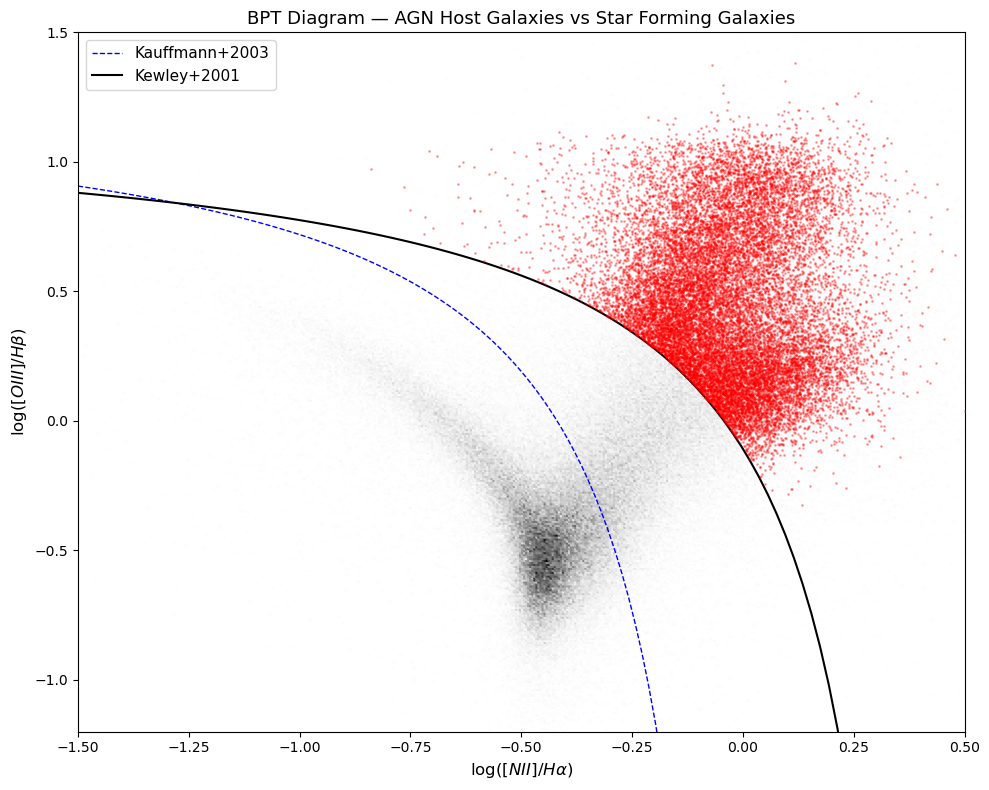

In [40]:
# When plotting the graph was too large in width and height because the 
# values of a couple of things were very very close to 0 flux producing very large log values
# so we should cut off the bpt_x and bpt_y at a value
# Physically -1.5 <= x <= 0.5 and -1.2<= y <= 1.5 makes sense (checked from internet)
# 

fig, ax = plt.subplots(figsize = (10,8))

ax.hexbin(bpt_sample['bpt_x'], bpt_sample['bpt_y'], gridsize = 3000, cmap = 'Greys', mincnt = 1)
ax.scatter(agn['bpt_x'], agn['bpt_y'], color = 'red', alpha = 0.3, zorder = 3, s = 1)
ax.set_xlabel(r'$\log([NII]/H\alpha)$', fontsize=12)
ax.set_ylabel(r'$\log([OIII]/H\beta)$', fontsize=12)
ax.set_xlim(-1.5, 0.5)
ax.set_ylim(-1.2, 1.5)


# Demarcation lines
x_kewley = np.linspace(-1.5, 0.45, 100)
y_kewley = 0.61 / (x_kewley - 0.47) + 1.19
#ax.plot(x_kewley, y_kewley, color = "black", linewidth = 1, linestyle = '-')

x_kauffmann = np.linspace(-1.5, 0.0, 100)
y_kauffmann = 0.61 / (x_kauffmann - 0.05) + 1.3

ax.plot(x_kauffmann, y_kauffmann, color='blue', linewidth=1, linestyle='--', label='Kauffmann+2003')
ax.plot(x_kewley, y_kewley, color='black', linewidth=1.5, linestyle='-', label='Kewley+2001')

## LEGEND
ax.legend(fontsize=11)
ax.set_title('BPT Diagram — AGN Host Galaxies vs Star Forming Galaxies', fontsize=13)

plt.tight_layout()
plt.savefig('../figures/BPT.pdf', dpi=300)
plt.show()

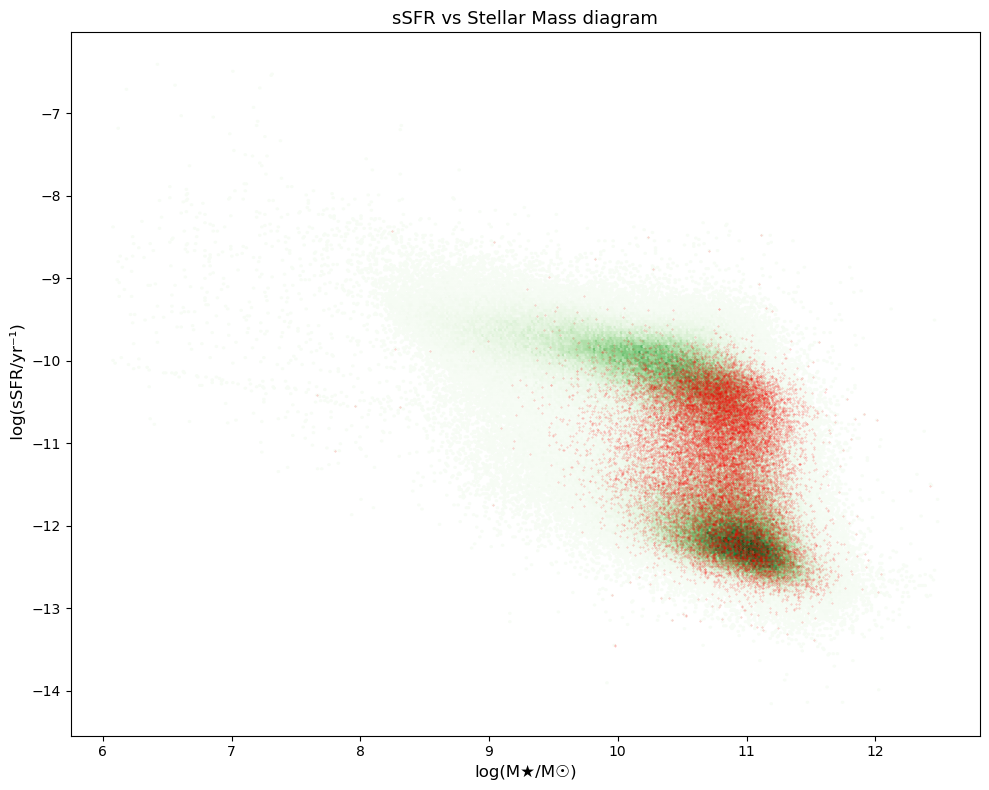

In [41]:
# 2nd diagram 

# print(sample['log_ssfr'].describe())
# print(agn['log_ssfr'].describe())
# All valyes seem to be okay, no extremums

fig2, ax2 = plt.subplots(figsize = (10,8))


#plotting log mass on x axis and log ssfr on y axis
ax2.hexbin(sample['log_mass'], sample['log_ssfr'], gridsize = 400, cmap = 'Greens', mincnt = 1)
ax2.scatter(agn['log_mass'], agn['log_ssfr'], color = 'red', alpha = 0.3, zorder = 3, s = 0.1)
ax2.set_xlabel('log(M★/M☉)', fontsize=12)
ax2.set_ylabel(' log(sSFR/yr⁻¹)', fontsize=12)
ax2.set_title('sSFR vs Stellar Mass diagram', fontsize = 13)

plt.tight_layout()
plt.savefig('../figures/ssfr_mass.pdf', dpi=300)
plt.show()

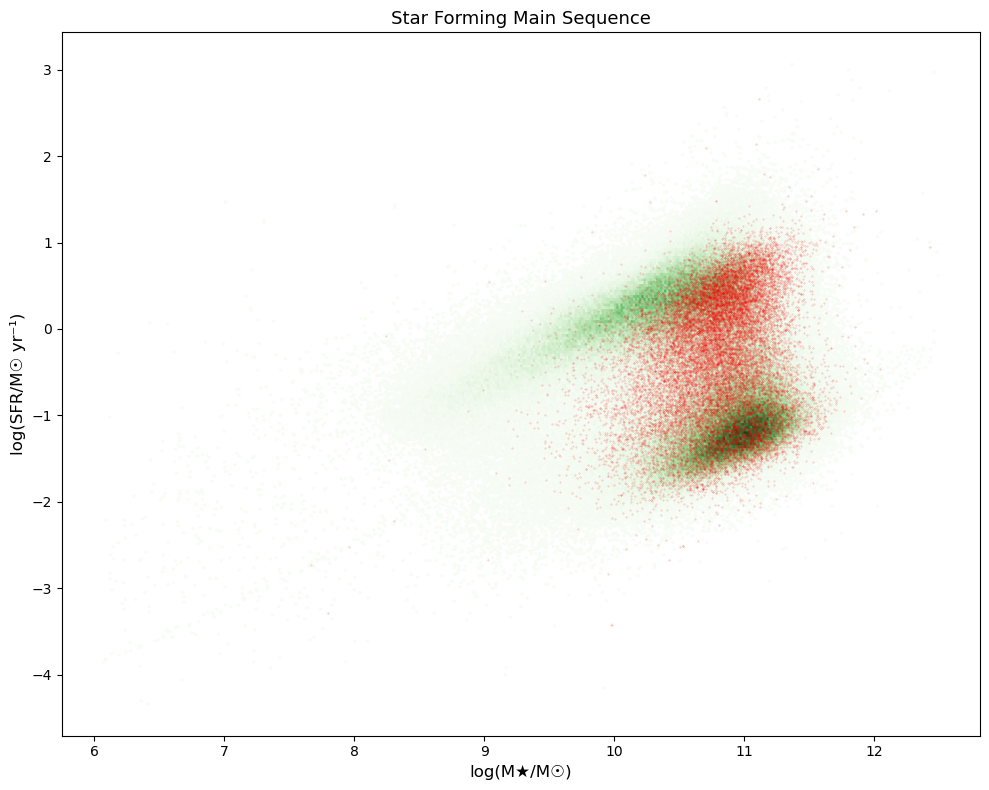

In [42]:
fig3, ax3 = plt.subplots(figsize = (10,8))

#plotting log mass on x axis and sfr on y axis
ax3.hexbin(sample['log_mass'], sample['sfr'], gridsize = 400, cmap = 'Greens', mincnt = 1)
ax3.scatter(agn['log_mass'], agn['sfr'], color = 'red', alpha = 0.3, zorder = 3, s = 0.1)
ax3.set_xlabel('log(M★/M☉)', fontsize=12)
ax3.set_ylabel('log(SFR/M☉ yr⁻¹)', fontsize=12)
ax3.set_title('Star Forming Main Sequence', fontsize = 13)

plt.tight_layout()
plt.savefig('../figures/star_forming_main_sequence.pdf', dpi=300)
plt.show()

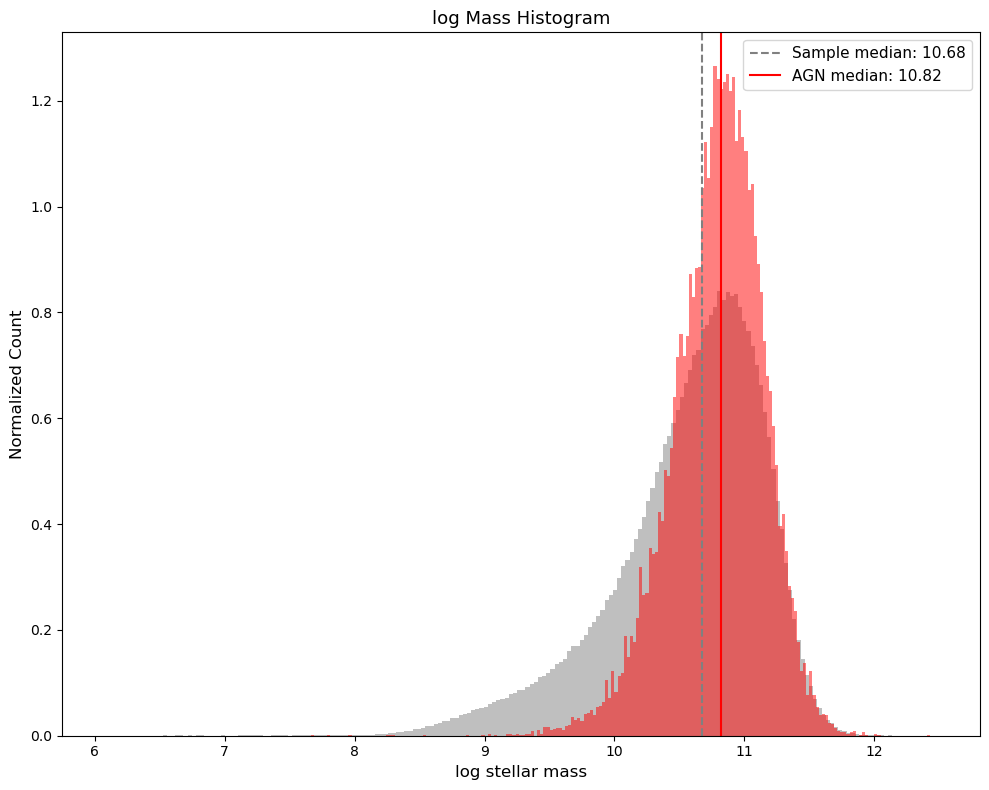

In [43]:
# Mass historgram

fig4, ax4 = plt.subplots(figsize = (10,8))

ax4.hist(sample['log_mass'], bins = 200, color = 'Grey', alpha = 0.5, density = True)
ax4.hist(agn['log_mass'], bins = 200, color = 'Red', alpha = 0.5, density = True)
ax4.set_xlabel('log stellar mass', fontsize = 12)
ax4.set_ylabel('Normalized Count', fontsize = 12)
ax4.set_title('log Mass Histogram', fontsize = 13)

ax4.axvline(sample['log_mass'].median(), color = 'grey', linestyle='--', linewidth=1.5, label=f'Sample median: {sample["log_mass"].median():.2f}')
ax4.axvline(agn['log_mass'].median(), color='red', linestyle='-', linewidth=1.5, label=f'AGN median: {agn["log_mass"].median():.2f}')
ax4.legend(fontsize=11)

plt.tight_layout()

plt.savefig('../figures/mass_histogram.pdf', dpi=300)
plt.show()
